In [1]:
# Initialize Otter. The try/except keeps the notebook runnable if otter is not installed locally.
try:
    import otter
    grader = otter.Notebook("hw5.ipynb")
except ModuleNotFoundError:
    grader = None

# CPSC 330 - Applied Machine Learning 

## Homework 5: Airbnb regression 
### Associated lectures: All material till lecture 13 

<div class="alert alert-info">

## Instructions
rubric={points}

You will earn points for following these instructions and successfully submitting your work in PrairieLearn.

### Group work instructions

**You may work with a partner on this homework and submit your assignment as a group.** Below are some instructions on working as a group.

- The maximum group size is 2.
- Use group work as an opportunity to collaborate and learn new things from each other.
- Be respectful to each other and make sure you understand all the concepts in the assignment well.
- It is your responsibility to make sure your PrairieLearn group is set up correctly and that the assignment is submitted before the deadline.

### General submission instructions

- Please read the [Use of Generative AI policy](https://ubc-cs.github.io/cpsc330-2026S1/syllabus#use-of-generative-ai-in-the-course) before starting the homework assignment.
- **Run all cells before submitting:** Go to `Kernel -> Restart Kernel and Clear All Outputs`, then select `Run -> Run All Cells`. This ensures your notebook runs cleanly from start to finish without errors.
- **Save your work in JupyterLab:** Make sure `hw5.ipynb` is saved.
- **Choose one HW5 option:** HW5 has two dataset options in PrairieLearn. You are currently in the Airbnb regression option. Open and submit exactly one notebook, and do not submit both.
- **Check your saved submission in PrairieLearn:** Return to the PrairieLearn question page and click **Save only** to capture your notebook and review the preview. When you are ready to submit for grading, click **Save & Grade**.
- **Follow course submission guidelines:** Review the [CPSC 330 homework instructions](https://ubc-cs.github.io/cpsc330-2026S1/docs/homework-instructions/) for detailed guidance on completing and submitting assignments.

</div>


_Note: Unlike previous assignments, this one is open-ended and project-style. Treat it as an opportunity to explore, experiment, and learn._

<!-- BEGIN QUESTION -->

## Imports

<div class="alert alert-warning">
    
Imports
    
</div>

_Points:_ 0

In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeRegressor

RANDOM_STATE = 123
pd.set_option("display.max_columns", None)

<!-- END QUESTION -->

## Introduction

In this homework you will be working on an open-ended mini-project, where you will put all the different things you have learned so far together to solve an interesting problem.

A few notes and tips when you work on this mini-project: 

#### Tips
1. This mini-project is open-ended, and while working on it, there might be some situations where you'll have to use your own judgment and make your own decisions (as you would be doing when you work as a data scientist). Make sure you explain your decisions whenever necessary. 
2. **Do not include everything you ever tried in your submission** -- it's fine just to have your final code. That said, your code should be reproducible and well-documented. For example, if you chose your hyperparameters based on some hyperparameter optimization experiment, you should leave in the code for that experiment so that someone else could re-run it and obtain the same hyperparameters, rather than mysteriously just setting the hyperparameters to some (carefully chosen) values in your code. 
3. If you realize that you are repeating a lot of code try to organize it in functions. Clear presentation of your code, experiments, and results is the key to be successful in this lab. You may use code from lecture notes or previous lab solutions with appropriate attributions. 

#### Assessment
We plan to grade fairly and leniently. We don't have some secret target score that you need to achieve to get a good grade. **You'll be assessed on demonstration of mastery of course topics, clear presentation, and the quality of your analysis and results.** For example, if you just have a bunch of code and no text or figures, that's not good. If you do a bunch of sane things and get a lower accuracy than your friend, don't sweat it.


#### A final note
Finally, this style of this "project" question is different from other assignments. It'll be up to you to decide when you're "done" -- in fact, this is one of the hardest parts of real projects. But please don't spend WAY too much time on this... perhaps "a few hours" (10-14 hours???) is a good guideline for this project . Of course if you're having fun you're welcome to spend as much time as you want! But, if so, try not to do it out of perfectionism or getting the best possible grade. Do it because you're learning and enjoying it. Students from the past cohorts have found such kind of labs useful and fun and I hope you enjoy it as well. 

<br><br>

<!-- BEGIN QUESTION -->

## 1. Pick your problem and explain the prediction problem
<hr>
rubric={points:3}

This version of Homework 5 uses the [New York City Airbnb Open Data dataset](https://www.kaggle.com/dgomonov/new-york-city-airbnb-open-data). You will work on a regression problem where the goal is to predict `reviews_per_month`, as a proxy for listing popularity. Airbnb could use this sort of model to predict how popular future listings might be before they are posted, perhaps to help guide hosts in creating more appealing listings. In reality they might instead use something like vacancy rate or average rating as their target, but we do not have that available here.

> Note there is an updated version of this dataset with more features available [here](http://insideairbnb.com/). The features we are using are in `listings.csv.gz` for the New York City dataset. You will also see some other files like `reviews.csv.gz`. For your own interest you may want to explore the expanded dataset and try your analysis there. However, please submit your results on the dataset obtained from Kaggle.

<div class="alert alert-info">
    
**Your tasks:**

1. Spend some time understanding the problem and what each feature means. You can find an explanation of the features [here](https://docs.google.com/spreadsheets/d/1iWCNJcSutYqpULSQHlNyGInUvHg2BoUGoNRIGa6Szc4/edit).
2. Download the dataset and load it into a pandas DataFrame.
3. Write a few sentences summarizing your initial thoughts about the problem and the dataset.
   
</div>


<div class="alert alert-warning">
    
Solution_1
    
</div>

_Points:_ 3

The prediction task is a supervised regression problem: predict `reviews_per_month`, which I am treating as a proxy for Airbnb listing popularity. A model like this could help estimate expected review activity for a new listing before it receives many reviews.

The raw data has 48,895 rows and 16 original columns. Some columns are directly related to review history, especially `number_of_reviews` and `last_review`; I will not use those as predictors because they leak information about the target and would not be available for a brand-new listing. The target has missing values for listings with no reviews, so I fill those values with `0`, meaning zero observed reviews per month. I will use location, room type, price/minimum-night information, availability, host listing count, and simple features derived from the listing name.

In [3]:
df = pd.read_csv("data/AB_NYC_2019.csv")

# In this dataset, missing reviews_per_month corresponds to listings with no reviews.
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
display(df.head())
display(df[["reviews_per_month", "price", "minimum_nights", "availability_365"]].describe())

Rows: 48,895
Columns: 16


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,0.00,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


,reviews_per_month,price,minimum_nights,availability_365
count,48895.000000,48895.000000,48895.000000,48895.000000
mean,1.090910,152.720687,7.029962,112.781327
std,1.597283,240.154170,20.510550,131.622289
min,0.000000,0.000000,1.000000,0.000000
25%,0.040000,69.000000,1.000000,0.000000
50%,0.370000,106.000000,3.000000,45.000000
75%,1.580000,175.000000,5.000000,227.000000
max,58.500000,10000.000000,1250.000000,365.000000


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 2. Data splitting
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. Split the data into train (70%) and test (30%) portions with `random_state=123`.

> If your computer cannot handle training on 70% training data, make the test split bigger.

</div>

<div class="alert alert-warning">
    
Solution_2
    
</div>

_Points:_ 2

In [4]:
train_df, test_df = train_test_split(df, test_size=0.3, random_state=RANDOM_STATE)

print("Training set shape:", train_df.shape)
print("Test set shape:", test_df.shape)

Training set shape: (34226, 16)
Test set shape: (14669, 16)


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 3. EDA
<hr>
rubric={points:10}

<div class="alert alert-info">

**Your tasks:**

1. **Perform exploratory data analysis (EDA)**: Conduct an initial exploration of the training set to better understand its characteristics.

2. **Summarize and visualize the data**: Include at least **two summary statistics** and **two visualizations** that you find informative. For each, write **one sentence** explaining what insight it provides.

3. **Record your observations**: Summarize your **initial observations** about the dataset based on your EDA.

4. **Select evaluation metrics**: Choose one or more **appropriate metrics** for assessing model performance and briefly justify your choice.

</div>

<div class="alert alert-warning">
    
Solution_3
    
</div>

_Points:_ 10

All EDA below is done on the training set only, so the test set remains untouched until the final evaluation. I focus on the target distribution, missingness, the main categorical variables, and numeric relationships with `reviews_per_month`.

In [5]:
missing_summary = train_df.isna().sum().sort_values(ascending=False).head(8).to_frame("missing_count")
target_summary = train_df["reviews_per_month"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]).to_frame().T

display(missing_summary)
display(target_summary)

,missing_count
last_review,6990
host_name,17
name,10
id,0
neighbourhood_group,0
neighbourhood,0
latitude,0
host_id,0


,count,mean,std,min,25%,50%,75%,90%,99%,max
reviews_per_month,34226.0,1.090058,1.614532,0.0,0.04,0.37,1.57,3.23,6.7675,58.5


In [6]:
room_type_summary = train_df.groupby("room_type").agg(
    count=("reviews_per_month", "size"),
    mean_reviews_per_month=("reviews_per_month", "mean"),
    median_reviews_per_month=("reviews_per_month", "median"),
    median_price=("price", "median"),
).sort_values("mean_reviews_per_month", ascending=False)

borough_summary = train_df.groupby("neighbourhood_group").agg(
    count=("reviews_per_month", "size"),
    mean_reviews_per_month=("reviews_per_month", "mean"),
    median_reviews_per_month=("reviews_per_month", "median"),
    median_price=("price", "median"),
).sort_values("mean_reviews_per_month", ascending=False)

display(room_type_summary)
display(borough_summary)

,count,mean_reviews_per_month,median_reviews_per_month,median_price
room_type,,,,
Private room,15565,1.142530,0.41,70.0
Entire home/apt,17848,1.046352,0.35,160.0
Shared room,813,1.044957,0.40,45.0


,count,mean_reviews_per_month,median_reviews_per_month,median_price
neighbourhood_group,,,,
Queens,3974,1.583694,0.77,75.0
Staten Island,255,1.523451,1.00,75.0
Bronx,771,1.461543,0.84,65.0
Brooklyn,14050,1.044762,0.38,92.0
Manhattan,15176,0.976574,0.28,150.0


In [7]:
numeric_for_eda = [
    "latitude",
    "longitude",
    "price",
    "minimum_nights",
    "calculated_host_listings_count",
    "availability_365",
    "reviews_per_month",
]

corr_with_target = (
    train_df[numeric_for_eda]
    .corr(numeric_only=True)["reviews_per_month"]
    .drop("reviews_per_month")
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .to_frame("correlation_with_reviews_per_month")
)
display(corr_with_target)

,correlation_with_reviews_per_month
availability_365,0.166157
longitude,0.140465
minimum_nights,-0.118284
price,-0.051542
calculated_host_listings_count,-0.046935
latitude,-0.020287


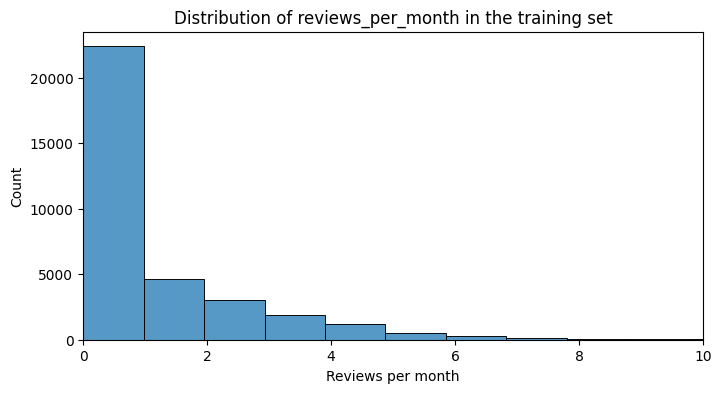

In [8]:
plt.figure(figsize=(8, 4))
sns.histplot(train_df["reviews_per_month"], bins=60)
plt.xlim(0, 10)
plt.xlabel("Reviews per month")
plt.title("Distribution of reviews_per_month in the training set")
plt.show()

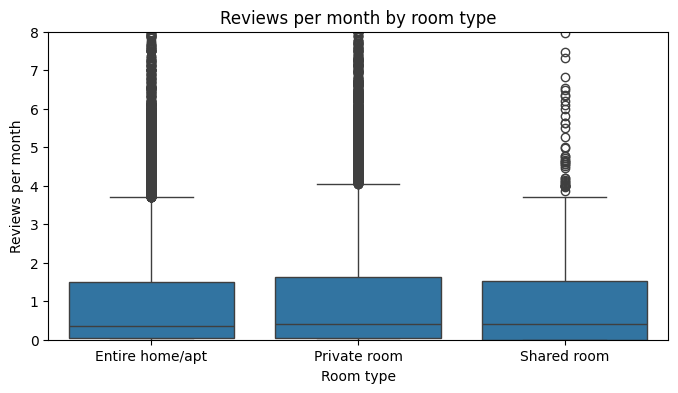

In [9]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=train_df, x="room_type", y="reviews_per_month")
plt.ylim(0, 8)
plt.xlabel("Room type")
plt.ylabel("Reviews per month")
plt.title("Reviews per month by room type")
plt.show()

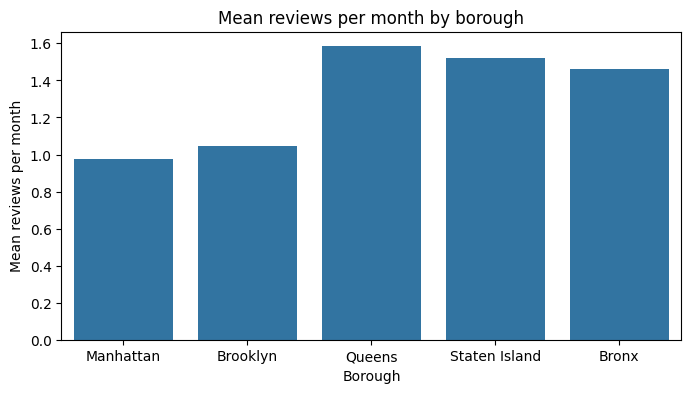

In [10]:
plt.figure(figsize=(8, 4))
sns.barplot(
    data=train_df,
    x="neighbourhood_group",
    y="reviews_per_month",
    estimator="mean",
    errorbar=None,
)
plt.xlabel("Borough")
plt.ylabel("Mean reviews per month")
plt.title("Mean reviews per month by borough")
plt.show()

Initial observations: the target is strongly right-skewed, with a median around 0.37 reviews/month and a much larger maximum value. Many listings have no observed review activity, so MAE is useful because it is more robust to the long right tail than RMSE. I will still report RMSE and R² as secondary metrics because RMSE shows sensitivity to large mistakes and R² gives a familiar variance-explained summary.

The most useful initial signals appear to be minimum-night requirements, availability, room type, and location. Longer minimum stays are negatively associated with monthly reviews, while listings with more availability tend to have higher observed review activity. Queens, Staten Island, and the Bronx have higher mean review activity than Brooklyn and Manhattan in this training split, although those group means should not be interpreted causally.

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 4. Feature engineering
<hr>
rubric={points:1}

<div class="alert alert-info">
    
**Your tasks:**

1. **Perform feature engineering**: Create new features that are relevant to the problem and use this updated feature set in the following exercises. You may need to iterate between **feature engineering** and **preprocessing** to refine your features and improve model performance.
   
</div>

<div class="alert alert-warning">
    
Solution_4
    
</div>

_Points:_ 1

I created features that should be available before a listing receives reviews. I used log transforms for skewed count/price variables and simple text-length features from the listing name. I deliberately exclude `number_of_reviews` and `last_review` from the modeling features because they are review-history variables and would leak target information.

In [11]:
def add_features(data):
    data = data.copy()
    name = data["name"].fillna("")
    data["name_length"] = name.str.len()
    data["name_word_count"] = name.str.split().str.len()
    data["has_name"] = (data["name_length"] > 0).astype(int)
    data["price_log"] = np.log1p(data["price"].clip(lower=0))
    data["minimum_nights_log"] = np.log1p(data["minimum_nights"].clip(lower=0))
    data["host_listing_count_log"] = np.log1p(
        data["calculated_host_listings_count"].clip(lower=0)
    )
    data["availability_ratio"] = data["availability_365"] / 365
    data["price_per_minimum_night_log"] = np.log1p(
        data["price"].clip(lower=0) * data["minimum_nights"].clip(lower=0)
    )
    return data

train_df = add_features(train_df)
test_df = add_features(test_df)

engineered_features = [
    "name_length",
    "name_word_count",
    "has_name",
    "price_log",
    "minimum_nights_log",
    "host_listing_count_log",
    "availability_ratio",
    "price_per_minimum_night_log",
]

display(train_df[engineered_features].head())

,name_length,name_word_count,has_name,price_log,minimum_nights_log,host_listing_count_log,availability_ratio,price_per_minimum_night_log
36150,38,7,1,4.574711,1.609438,0.693147,0.046575,5.953243
45223,47,8,1,5.017280,3.433987,3.044522,0.909589,8.412055
14316,33,4,1,5.303305,0.693147,0.693147,0.000000,5.303305
1691,29,4,1,4.564348,0.693147,0.693147,0.000000,4.564348
20195,43,5,1,5.298317,1.386294,0.693147,0.000000,6.393591


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 5. Preprocessing and transformations
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Identify feature types**: Determine the different types of features in your dataset (e.g., numerical, categorical, ordinal, text) and specify the transformations you would apply to each type.

2. **Define a column transformer (if needed)**: Implement a `ColumnTransformer` to apply the appropriate preprocessing steps to each feature type.
 
</div>

<div class="alert alert-warning">
    
Solution_5
    
</div>

_Points:_ 10

Feature types and transformations:

- Numeric features: latitude/longitude plus engineered log, availability, and name-length features. I impute missing values with the median and scale them for the Ridge and feature-selection models.
- Categorical features: borough, neighbourhood, and room type. I impute missing values with the most frequent value and one-hot encode them.
- Dropped/leakage features: `id`, `host_id`, `host_name`, raw `name`, `number_of_reviews`, and `last_review`. The review-history columns are not valid predictors for the intended future-listing use case.

In [12]:
numeric_features = [
    "latitude",
    "longitude",
    "price_log",
    "minimum_nights_log",
    "host_listing_count_log",
    "availability_ratio",
    "name_length",
    "name_word_count",
    "price_per_minimum_night_log",
]

categorical_features = ["neighbourhood_group", "neighbourhood", "room_type"]
model_features = numeric_features + categorical_features

target = "reviews_per_month"
X_train = train_df[model_features]
y_train = train_df[target]
X_test = test_df[model_features]
y_test = test_df[target]

feature_type_table = pd.DataFrame(
    {
        "feature": model_features,
        "type": ["numeric"] * len(numeric_features) + ["categorical"] * len(categorical_features),
        "transformation": ["median imputation + standard scaling"] * len(numeric_features)
        + ["most frequent imputation + one-hot encoding"] * len(categorical_features),
    }
)
display(feature_type_table)

,feature,type,transformation
0,latitude,numeric,median imputation + standard scaling
1,longitude,numeric,median imputation + standard scaling
2,price_log,numeric,median imputation + standard scaling
3,minimum_nights_log,numeric,median imputation + standard scaling
4,host_listing_count_log,numeric,median imputation + standard scaling
5,availability_ratio,numeric,median imputation + standard scaling
6,name_length,numeric,median imputation + standard scaling
7,name_word_count,numeric,median imputation + standard scaling
8,price_per_minimum_night_log,numeric,median imputation + standard scaling
9,neighbourhood_group,categorical,most frequent imputation + one-hot encoding


In [13]:
def make_preprocessor():
    numeric_transformer = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )
    categorical_transformer = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]
    )
    return ColumnTransformer(
        [
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features),
        ]
    )


def make_pipeline(model):
    return Pipeline([("preprocessor", make_preprocessor()), ("model", model)])

preprocessor = make_preprocessor()
preprocessor

In [14]:
def summarize_cv(name, estimator, X, y, cv=3):
    scoring = {
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2",
    }
    scores = cross_validate(
        estimator,
        X,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=1,
    )
    return {
        "model": name,
        "train_rmse": -scores["train_rmse"].mean(),
        "valid_rmse": -scores["test_rmse"].mean(),
        "valid_rmse_std": scores["test_rmse"].std(),
        "train_mae": -scores["train_mae"].mean(),
        "valid_mae": -scores["test_mae"].mean(),
        "valid_mae_std": scores["test_mae"].std(),
        "valid_r2": scores["test_r2"].mean(),
        "fit_time": scores["fit_time"].mean(),
        "score_time": scores["score_time"].mean(),
    }


def evaluate_model(estimator, X, y):
    pred = estimator.predict(X)
    return {
        "rmse": mean_squared_error(y, pred) ** 0.5,
        "mae": mean_absolute_error(y, pred),
        "r2": r2_score(y, pred),
    }

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 6. Baseline model
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. **Establish a baseline**: Use one of `scikit-learn`’s baseline models (e.g., `DummyClassifier` or `DummyRegressor`, depending on your task) and report the results. This will serve as a reference point for evaluating the performance of your more advanced models.

</div>

<div class="alert alert-warning">
    
Solution_6
    
</div>

_Points:_ 2

In [15]:
baseline_pipe = make_pipeline(DummyRegressor(strategy="mean"))
baseline_cv = summarize_cv("DummyRegressor(mean)", baseline_pipe, X_train, y_train)

display(pd.DataFrame([baseline_cv]).round(4))

,model,train_rmse,valid_rmse,valid_rmse_std,train_mae,valid_mae,valid_mae_std,valid_r2,fit_time,score_time
0,DummyRegressor(mean),1.6144,1.6142,0.0324,1.1483,1.1483,0.0044,-0.0,0.1154,0.0432


The baseline predicts the mean training target for every listing. Its validation MAE is about 1.148 reviews/month and its R² is essentially 0, so any useful model should clearly beat this.

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 7. Linear models 
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Train a linear model**: Use a linear model as your first real attempt at solving the problem.

2. **Tune hyperparameters**: Perform hyperparameter tuning to explore different values of the model's complexity parameter. 

3. **Evaluate with cross-validation**: Report the cross-validation scores along with their standard deviation.

4. **Summarize findings**: Summarize your results, highlighting key observations from your experiments.

</div>

<div class="alert alert-warning">
    
Solution_7
    
</div>

_Points:_ 10

In [16]:
ridge_search = GridSearchCV(
    make_pipeline(Ridge()),
    param_grid={"model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]},
    scoring="neg_mean_absolute_error",
    cv=3,
    n_jobs=1,
    return_train_score=True,
)
ridge_search.fit(X_train, y_train)

ridge_results = pd.DataFrame(ridge_search.cv_results_)[
    ["param_model__alpha", "mean_train_score", "mean_test_score", "std_test_score"]
].copy()
ridge_results["mean_train_mae"] = -ridge_results["mean_train_score"]
ridge_results["mean_valid_mae"] = -ridge_results["mean_test_score"]
ridge_results["std_valid_mae"] = ridge_results["std_test_score"]
ridge_results = ridge_results[
    ["param_model__alpha", "mean_train_mae", "mean_valid_mae", "std_valid_mae"]
]

print("Best Ridge parameters:", ridge_search.best_params_)
display(ridge_results.round(4))

Best Ridge parameters: {'model__alpha': 10.0}


,param_model__alpha,mean_train_mae,mean_valid_mae,std_valid_mae
0,0.01,0.9965,1.0073,0.0033
1,0.10,0.9965,1.0072,0.0033
2,1.00,0.9970,1.0063,0.0032
3,10.00,0.9997,1.0059,0.0028
4,100.00,1.0059,1.0088,0.0028


In [17]:
ridge_best = ridge_search.best_estimator_
ridge_cv = summarize_cv("Ridge(best alpha)", ridge_best, X_train, y_train)
display(pd.DataFrame([ridge_cv]).round(4))

,model,train_rmse,valid_rmse,valid_rmse_std,train_mae,valid_mae,valid_mae_std,valid_r2,fit_time,score_time
0,Ridge(best alpha),1.4538,1.4632,0.0366,0.9997,1.0059,0.0028,0.1784,0.1537,0.0424


The best Ridge value is `alpha=10.0`. Ridge improves the validation MAE from the dummy baseline's roughly 1.148 to roughly 1.006, so the engineered features and categorical variables are informative. The training and validation errors are similar, which suggests Ridge is not badly overfitting; however, its validation R² of about 0.18 indicates that the linear model is still underfitting the non-linear structure in the data.

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 8. Different models
<hr>
rubric={points:12}

<div class="alert alert-info">
    
**Your tasks:**

1. **Experiment with additional models**: Train at least **three models** other than a linear model. Ensure that **at least one** of these models is a **tree-based ensemble model** (e.g., Random Forest, Gradient Boosting, or XGBoost).

2. **Compare and interpret results**: Summarize your findings in terms of **overfitting/underfitting** behavior and **fit/score times** for each model. Reflect on your results. Were you able to **outperform the linear model**?

</div>

<div class="alert alert-warning">
    
Solution_8
    
</div>

_Points:_ 12

In [18]:
models = [
    (
        "DecisionTreeRegressor(max_depth=10)",
        make_pipeline(DecisionTreeRegressor(max_depth=10, random_state=RANDOM_STATE)),
    ),
    (
        "RandomForestRegressor",
        make_pipeline(
            RandomForestRegressor(
                n_estimators=60,
                max_depth=14,
                min_samples_leaf=5,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )
        ),
    ),
    (
        "HistGradientBoostingRegressor",
        make_pipeline(
            HistGradientBoostingRegressor(
                max_iter=150,
                learning_rate=0.08,
                max_leaf_nodes=31,
                l2_regularization=0.0,
                random_state=RANDOM_STATE,
            )
        ),
    ),
]

model_results = [summarize_cv(name, pipe, X_train, y_train) for name, pipe in models]
model_results_df = pd.DataFrame(model_results).sort_values("valid_mae")
display(model_results_df.round(4))

,model,train_rmse,valid_rmse,valid_rmse_std,train_mae,valid_mae,valid_mae_std,valid_r2,fit_time,score_time
2,HistGradientBoostingRegressor,1.1460,1.2780,0.0385,0.7272,0.7885,0.0051,0.3732,4.4575,0.0916
1,RandomForestRegressor,1.0883,1.2849,0.0357,0.6599,0.7927,0.0046,0.3665,2.3791,0.0930
0,DecisionTreeRegressor(max_depth=10),1.2127,1.3799,0.0634,0.7494,0.8296,0.0052,0.2691,0.5273,0.0477


All three non-linear models outperform Ridge. The single decision tree improves substantially but has a larger train-validation gap, which is a sign of overfitting. Random forest and histogram gradient boosting are both stronger; histogram gradient boosting has the best validation MAE at about 0.788 and the best validation R² at about 0.37. Fit times are still reasonable, although the ensemble models are slower than Ridge and the dummy baseline.

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 9. Feature selection 
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. **Perform feature selection**: Attempt to select relevant features using methods such as `RFECV` or forward selection.

2. **Evaluate the impact** Compare the model performance before and after feature selection. Do the results improve with feature selection?

3. **Summarize findings** Summarize your observations and decide whether to **keep feature selection** in your pipeline.  If it improves results, retain it for the next exercises; otherwise, you may choose to omit it.
</div>

<div class="alert alert-warning">
    
Solution_9
    
</div>

_Points:_ 2

In [19]:
feature_selection_pipe = Pipeline(
    [
        ("preprocessor", make_preprocessor()),
        ("select", SelectKBest(score_func=f_regression, k=40)),
        ("model", Ridge(alpha=ridge_search.best_params_["model__alpha"])),
    ]
)

feature_selection_cv = summarize_cv(
    "Ridge + SelectKBest(k=40)", feature_selection_pipe, X_train, y_train
)
feature_selection_comparison = pd.DataFrame([ridge_cv, feature_selection_cv])
display(feature_selection_comparison.round(4))

,model,train_rmse,valid_rmse,valid_rmse_std,train_mae,valid_mae,valid_mae_std,valid_r2,fit_time,score_time
0,Ridge(best alpha),1.4538,1.4632,0.0366,0.9997,1.0059,0.0028,0.1784,0.1537,0.0424
1,Ridge + SelectKBest(k=40),1.4607,1.4654,0.0359,1.0059,1.0085,0.0027,0.1759,0.1520,0.0461


Feature selection did not improve performance here: the selected-feature Ridge model has a validation MAE of about 1.009, slightly worse than the full Ridge model at about 1.006. I would not keep feature selection in the final pipeline because the one-hot encoded categories and engineered numeric features appear useful enough that removing many of them hurts more than it helps.

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 10. Hyperparameter optimization
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Optimize hyperparameters**: Attempt to optimize hyperparameters for the models you have tried so far. In at least **one case**, tune **multiple hyperparameters** for a single model.

2. **Use suitable optimization methods**: You may use any of the following approaches for hyperparameter optimization:
   - [`GridSearchCV`](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)  
   - [`RandomizedSearchCV`](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html)  
   - [Bayesian optimization with scikit-optimize](https://github.com/scikit-optimize/scikit-optimize)

3. **Summarize your results**: Report and compare the optimized results across models. Discuss whether hyperparameter optimization led to performance improvements.

</div>

<div class="alert alert-warning">
    
Solution_10
    
</div>

_Points:_ 10

In [20]:
hgb_search = GridSearchCV(
    make_pipeline(HistGradientBoostingRegressor(random_state=RANDOM_STATE)),
    param_grid={
        "model__max_iter": [100, 200],
        "model__learning_rate": [0.05, 0.1],
        "model__max_leaf_nodes": [15, 31],
        "model__l2_regularization": [0.0, 0.1],
    },
    scoring="neg_mean_absolute_error",
    cv=3,
    n_jobs=1,
    return_train_score=True,
)
hgb_search.fit(X_train, y_train)

hgb_grid = pd.DataFrame(hgb_search.cv_results_).sort_values("rank_test_score")
hgb_grid_display = hgb_grid[
    [
        "param_model__max_iter",
        "param_model__learning_rate",
        "param_model__max_leaf_nodes",
        "param_model__l2_regularization",
        "mean_train_score",
        "mean_test_score",
        "std_test_score",
        "mean_fit_time",
    ]
].copy()
hgb_grid_display["mean_train_mae"] = -hgb_grid_display["mean_train_score"]
hgb_grid_display["mean_valid_mae"] = -hgb_grid_display["mean_test_score"]
hgb_grid_display["std_valid_mae"] = hgb_grid_display["std_test_score"]
hgb_grid_display = hgb_grid_display.drop(
    columns=["mean_train_score", "mean_test_score", "std_test_score"]
)

print("Best HGB parameters:", hgb_search.best_params_)
display(hgb_grid_display.head(8).round(4))

Best HGB parameters: {'model__l2_regularization': 0.1, 'model__learning_rate': 0.1, 'model__max_iter': 200, 'model__max_leaf_nodes': 31}


,param_model__max_iter,param_model__learning_rate,param_model__max_leaf_nodes,param_model__l2_regularization,mean_fit_time,mean_train_mae,mean_valid_mae,std_valid_mae
15,200,0.10,31,0.1,3.2624,0.7200,0.7867,0.0055
13,100,0.10,31,0.1,2.8103,0.7214,0.7868,0.0056
3,200,0.05,31,0.0,4.0842,0.7360,0.7902,0.0059
5,100,0.10,31,0.0,1.8137,0.7461,0.7918,0.0055
7,200,0.10,31,0.0,1.8513,0.7461,0.7918,0.0055
11,200,0.05,31,0.1,3.4553,0.7469,0.7943,0.0046
1,100,0.05,31,0.0,3.0144,0.7530,0.7950,0.0071
6,200,0.10,15,0.0,1.8927,0.7601,0.7955,0.0081


In [21]:
best_model = hgb_search.best_estimator_
hgb_cv = summarize_cv("Tuned HistGradientBoostingRegressor", best_model, X_train, y_train)
display(pd.DataFrame([hgb_cv]).round(4))

,model,train_rmse,valid_rmse,valid_rmse_std,train_mae,valid_mae,valid_mae_std,valid_r2,fit_time,score_time
0,Tuned HistGradientBoostingRegressor,1.1354,1.2764,0.036,0.72,0.7867,0.0055,0.3748,3.0378,0.1053


The tuned histogram gradient boosting model is the final model. The best parameters are `max_iter=200`, `learning_rate=0.1`, `max_leaf_nodes=31`, and `l2_regularization=0.1`. Hyperparameter tuning gives a small but real improvement over the initial histogram gradient boosting model, reducing validation MAE from about 0.788 to about 0.787. Since the search was repeated over several settings, there is some risk of optimization bias, so the final test evaluation is important.

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 11. Interpretation and feature importances
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Interpret model feature importance**: Use one of the interpretation methods discussed in class (e.g., `shap`), or another suitable method of your choice, to examine the most important features of one of your **non-linear models**.

2. **Summarize insights**: Summarize your observations about which features contribute most to the model's predictions and how they influence the outcomes.

   
</div>

<div class="alert alert-warning">
    
Solution_11
    
</div>

_Points:_ 10

In [22]:
importance_sample = X_train.sample(n=min(3000, len(X_train)), random_state=RANDOM_STATE)
importance_y = y_train.loc[importance_sample.index]

perm = permutation_importance(
    best_model,
    importance_sample,
    importance_y,
    scoring="neg_mean_absolute_error",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

permutation_importance_df = pd.DataFrame(
    {
        "feature": model_features,
        "importance_mean_mae_decrease": perm.importances_mean,
        "importance_std": perm.importances_std,
    }
).sort_values("importance_mean_mae_decrease", ascending=False)

display(permutation_importance_df.head(10).round(4))

,feature,importance_mean_mae_decrease,importance_std
5,availability_ratio,0.3308,0.0073
3,minimum_nights_log,0.1218,0.0109
8,price_per_minimum_night_log,0.0627,0.0091
11,room_type,0.0490,0.0063
4,host_listing_count_log,0.0409,0.0014
6,name_length,0.0292,0.0043
10,neighbourhood,0.0249,0.0027
1,longitude,0.0227,0.0017
0,latitude,0.0206,0.0012
2,price_log,0.0108,0.0016


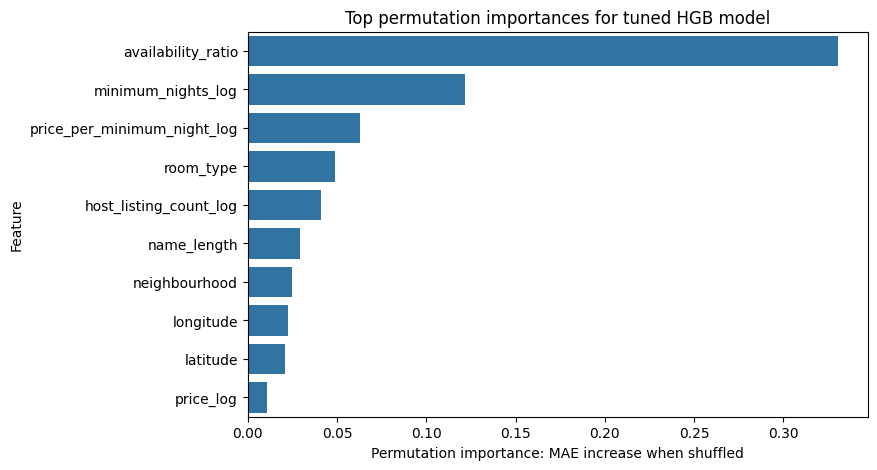

In [23]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=permutation_importance_df.head(10),
    x="importance_mean_mae_decrease",
    y="feature",
    orient="h",
)
plt.xlabel("Permutation importance: MAE increase when shuffled")
plt.ylabel("Feature")
plt.title("Top permutation importances for tuned HGB model")
plt.show()

The most important feature is `availability_ratio`, followed by minimum-night and price/minimum-night features. This suggests the model relies heavily on how available a listing is and how restrictive or costly a booking is. `room_type`, host listing count, neighbourhood, and coordinates also matter, which is sensible because location and accommodation type are central to Airbnb demand. These are permutation importances, so they describe predictive usefulness for this fitted model rather than causal effects.

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 12. Results on the test set
<hr>

rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Evaluate on the test set**: Apply your best-performing model to the test data and report the test scores.

2. **Compare and reflect**: Compare the **test scores** with the **validation scores** from previous experiments. Discuss the consistency between them. How much do you **trust your results**? Reflect on whether you might have encountered **optimization bias**.

3. **Explain individual predictions**: Select one or two examples from your test predictions and use an interpretation method (e.g., **SHAP force plots**) to explain these individual predictions.
</div>

<div class="alert alert-warning">
    
Solution_12
    
</div>

_Points:_ 10

In [24]:
test_scores = evaluate_model(best_model, X_test, y_test)
display(pd.DataFrame([test_scores]).round(4))

,rmse,mae,r2
0,1.2116,0.7831,0.3939


In [25]:
def build_reference_row(X):
    reference = {}
    for col in numeric_features:
        reference[col] = X[col].median()
    for col in categorical_features:
        reference[col] = X[col].mode().iloc[0]
    return reference


def local_what_if_explanation(model, row, reference_row, features):
    base_pred = model.predict(row)[0]
    rows = []
    for feature in features:
        changed = row.copy()
        changed[feature] = reference_row[feature]
        changed_pred = model.predict(changed)[0]
        rows.append(
            {
                "feature": feature,
                "value": row[feature].iloc[0],
                "reference_value": reference_row[feature],
                "prediction": base_pred,
                "prediction_if_reference": changed_pred,
                "delta_if_reference": changed_pred - base_pred,
            }
        )
    return pd.DataFrame(rows)

reference_row = build_reference_row(X_train)
top_explanation_features = permutation_importance_df.head(5)["feature"].tolist()
example_indices = X_test.index[:2].tolist()

for idx in example_indices:
    row = X_test.loc[[idx]]
    prediction = best_model.predict(row)[0]
    print(f"Test example {idx}: predicted={prediction:.3f}, actual={y_test.loc[idx]:.3f}")
    display(local_what_if_explanation(best_model, row, reference_row, top_explanation_features).round(4))

Test example 29122: predicted=0.343, actual=0.000
Test example 2964: predicted=2.749, actual=1.930


,feature,value,reference_value,prediction,prediction_if_reference,delta_if_reference
0,availability_ratio,0.0,0.123288,0.3434,1.7175,1.3740
1,minimum_nights_log,1.386294,1.386294,0.3434,0.3434,0.0000
2,price_per_minimum_night_log,4.663439,5.70711,0.3434,0.3173,-0.0261
3,room_type,Private room,Entire home/apt,0.3434,0.3871,0.0437
4,host_listing_count_log,0.693147,0.693147,0.3434,0.3434,0.0000


,feature,value,reference_value,prediction,prediction_if_reference,delta_if_reference
0,availability_ratio,0.041096,0.123288,2.7495,3.0997,0.3502
1,minimum_nights_log,0.693147,1.386294,2.7495,2.1244,-0.6250
2,price_per_minimum_night_log,4.454347,5.70711,2.7495,1.8280,-0.9215
3,room_type,Private room,Entire home/apt,2.7495,3.1170,0.3675
4,host_listing_count_log,0.693147,0.693147,2.7495,2.7495,0.0000


The tuned model achieves a test MAE of about 0.783 reviews/month, RMSE about 1.212, and R² about 0.394. The test MAE is very close to the cross-validation MAE of about 0.787, so the result looks reasonably consistent rather than obviously overfit to validation folds. I still would not overstate the model, because the target is noisy, review behavior is only a proxy for popularity, and we did tune multiple models.

For the individual examples, I used a local what-if interpretation: replace each top feature with a typical training-set reference value and measure how the prediction changes. This is not a causal explanation, but it shows which features the fitted model is most sensitive to for those specific listings.

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 13. Summary of results
<hr>
rubric={points:12}

Imagine you are preparing to present the summary of your results to your boss and co-workers.

<div class="alert alert-info">
    
**Your tasks:**

1. **Summarize key results**: Create a clear and concise table highlighting your most important results (e.g., models compared, validation/test scores, key observations).

2. **Write concluding remarks**: Summarize your main takeaways from the project, including what worked well and what did not.

3. **Propose future improvements**: Discuss ideas or approaches you did not try but that could potentially improve **performance** or **interpretability**.

4. **Report final results**: Report your **final test score** and the **metric** you used.

</div>


<div class="alert alert-warning">
    
Solution_13
    
</div>

_Points:_ 12

In [26]:
summary_rows = [baseline_cv, ridge_cv] + model_results + [feature_selection_cv, hgb_cv]
summary_table = pd.DataFrame(summary_rows)[
    [
        "model",
        "train_mae",
        "valid_mae",
        "valid_mae_std",
        "valid_rmse",
        "valid_r2",
        "fit_time",
        "score_time",
    ]
].sort_values("valid_mae")

summary_table["test_mae"] = np.nan
summary_table["test_rmse"] = np.nan
summary_table["test_r2"] = np.nan
summary_table.loc[
    summary_table["model"] == "Tuned HistGradientBoostingRegressor",
    ["test_mae", "test_rmse", "test_r2"],
] = [test_scores["mae"], test_scores["rmse"], test_scores["r2"]]

display(summary_table.round(4))

,model,train_mae,valid_mae,valid_mae_std,valid_rmse,valid_r2,fit_time,score_time,test_mae,test_rmse,test_r2
6,Tuned HistGradientBoostingRegressor,0.7200,0.7867,0.0055,1.2764,0.3748,3.0378,0.1053,0.7831,1.2116,0.3939
4,HistGradientBoostingRegressor,0.7272,0.7885,0.0051,1.2780,0.3732,4.4575,0.0916,NaN,NaN,NaN
3,RandomForestRegressor,0.6599,0.7927,0.0046,1.2849,0.3665,2.3791,0.0930,NaN,NaN,NaN
2,DecisionTreeRegressor(max_depth=10),0.7494,0.8296,0.0052,1.3799,0.2691,0.5273,0.0477,NaN,NaN,NaN
1,Ridge(best alpha),0.9997,1.0059,0.0028,1.4632,0.1784,0.1537,0.0424,NaN,NaN,NaN
5,Ridge + SelectKBest(k=40),1.0059,1.0085,0.0027,1.4654,0.1759,0.1520,0.0461,NaN,NaN,NaN
0,DummyRegressor(mean),1.1483,1.1483,0.0044,1.6142,-0.0000,0.1154,0.0432,NaN,NaN,NaN


The best final model is the tuned histogram gradient boosting regressor. Using MAE as the main metric, it reaches a validation MAE of about 0.787 and a final test MAE of about 0.783 reviews/month. It also improves R² to about 0.394 on the test set, compared with roughly 0 for the dummy baseline and about 0.178 for Ridge.

The biggest improvement came from moving from a linear model to tree-based non-linear models. Ridge was stable but underfit; the single decision tree improved MAE but showed more overfitting; random forest and histogram gradient boosting gave the strongest results. Feature selection did not help in this setup.

Future improvements could include richer text features from the listing name, better treatment of zero-inflated targets, more careful outlier handling for extreme prices and minimum-night values, and an expanded dataset with calendar availability, reviews, or rating information. For interpretability, SHAP would be a stronger option than permutation and what-if explanations if the package were available.

<!-- END QUESTION -->

<br><br>

<br><br>

<!-- BEGIN QUESTION -->

## 14. Your takeaway
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

What is your biggest takeaway from the supervised machine learning material we have learned so far? Please write thoughtful answers.  

</div>

<div class="alert alert-warning">
    
Solution_14
    
</div>

_Points:_ 2

My biggest takeaway is that supervised machine learning is less about picking one impressive model and more about building a careful workflow. Splitting data correctly, avoiding leakage, choosing a metric that matches the problem, setting up preprocessing inside a pipeline, and comparing models against a baseline matter just as much as the final algorithm. I also learned that validation performance is only trustworthy when the whole process is reproducible and when the final test set is kept genuinely separate until the end.

<!-- END QUESTION -->

<br><br>

Before submitting your assignment, please make sure you have followed all the instructions in the Instructions section at the top.

Here is a quick checklist before submitting:

- [ ] Restart the kernel and run all cells.
- [ ] `hw5.ipynb` runs without errors and contains all outputs.
- [ ] Save `hw5.ipynb` in JupyterLab.
- [ ] Return to the PrairieLearn question page and click **Save only** to check the rendered notebook preview.
- [ ] When the preview looks correct, click **Save & Grade**.
- [ ] If you are working in a group, confirm your PrairieLearn group membership is correct.
- [ ] Review the [CPSC 330 homework instructions](https://ubc-cs.github.io/cpsc330-2026S1/docs/homework-instructions/) for details on the grading process.


This was a tricky one but you did it 👏👏!  

![](img/eva-well-done.png)